# Inference & Analysis Notebook — Vision Transformer Gradient Flow
## Saliency Maps, Jacobian Condition Numbers & Gradient Flow Visualization

**Author:** Nikolaos Mavros — University of Thessaly, ECE452  
**Repo:** `vit-gradient-flow`

This notebook loads the trained ViT weights saved by `train_vit.ipynb` and produces all three analytical outputs described in the proposal:

1. **Saliency maps** — $\partial\text{Output}/\partial\text{Input}$ for Xavier vs Orthogonal models  
2. **Jacobian condition number plots** — evolution of $\kappa(J)$ across training epochs  
3. **Gradient norm heatmaps** — per-layer gradient norms, Xavier vs Orthogonal

> **Prerequisites:** Run `train_vit.ipynb` first. It saves weights to `results/vit_weights_xavier.jld2`, `results/vit_weights_orthogonal.jld2`, and logs to `results/logs/`.

## 1. Environment Setup

In [1]:
using Pkg
Pkg.activate("..")   # repo root (one level up from notebooks/)
Pkg.add("StatsPlots") # FIX: Explicitly add the missing package to the environment
Pkg.instantiate()

using Flux
using Flux: onehotbatch, onecold, DataLoader
using Zygote
using MLDatasets
using LinearAlgebra
using Statistics
using Random
using JLD2
using Plots
using StatsPlots   # for groupedbar

println("All packages loaded.")

  Activating project at `c:\Users\nickb\Documents\vit-gradient-flow`
   Resolving package versions...
     Project No packages added to or removed from `C:\Users\nickb\Documents\vit-gradient-flow\Project.toml`
    Manifest No packages added to or removed from `C:\Users\nickb\Documents\vit-gradient-flow\Manifest.toml`
Precompiling packages...
   1600.4 ms  ✓ Pango_jll
┌ Warning: attempting to remove probably stale pidfile
│   path = C:\Users\nickb\.julia\compiled\v1.12\StatsPlots\SiylL_DmpyH.ji.pidfile
└ @ FileWatching.Pidfile C:\Users\nickb\.julia\juliaup\julia-1.12.5+0.x64.w64.mingw32\share\julia\stdlib\v1.12\FileWatching\src\pidfile.jl:247
   6032.4 ms  ✓ Plots → FileIOExt
   6313.4 ms  ✓ Plots → UnitfulExt
   8955.4 ms  ✓ StatsPlots
  4 dependencies successfully precompiled in 14 seconds. 418 already precompiled.


All packages loaded.


## 2. Hyperparameters

Must match exactly what was used in `train_vit.ipynb`.

In [4]:
# ── Image & Patch geometry ────────────────────────────────────────────────
const IMG_SIZE      = 28
const PATCH_SIZE    = 7
const NUM_PATCHES   = (IMG_SIZE ÷ PATCH_SIZE)^2   # 16
const PATCH_DIM     = PATCH_SIZE * PATCH_SIZE      # 49

# ── Transformer architecture ─────────────────────────────────────────────
const D_MODEL       = 64
const NUM_HEADS     = 4
const HEAD_DIM      = D_MODEL ÷ NUM_HEADS          # 16
const MLP_HIDDEN    = 128
const NUM_BLOCKS    = 2
const NUM_CLASSES   = 10

# ── Output directory ─────────────────────────────────────────────────────
const OUT_DIR = joinpath("..", "results")
mkpath(joinpath(OUT_DIR, "figures"))

println("Hyperparameters set ✓")
println("  Patches per image: $NUM_PATCHES  |  Patch dim: $PATCH_DIM")
println("  Model dim: $D_MODEL  |  Heads: $NUM_HEADS  |  Blocks: $NUM_BLOCKS")

Hyperparameters set ✓
  Patches per image: 16  |  Patch dim: 49
  Model dim: 64  |  Heads: 4  |  Blocks: 2


## 3. Model Architecture

Exact copy from the training notebook — all four structs must be re-defined in this session so Flux can reconstruct the model state from the `.jld2` files.

In [5]:
# ── Initializers ─────────────────────────────────────────────────────────
function xavier_init(dims...)
    return Flux.glorot_uniform(dims...)
end

function orthogonal_init(dims...)
    return Flux.orthogonal(dims...)
end

# ── PatchEmbedding ────────────────────────────────────────────────────────
struct PatchEmbedding
    proj::Dense
    cls_token::AbstractArray{Float32, 2}
    pos_embed::AbstractArray{Float32, 2}
end

Flux.@layer PatchEmbedding

function PatchEmbedding(init_fn)
    proj = Dense(init_fn(D_MODEL, PATCH_DIM), zeros(Float32, D_MODEL))
    cls  = randn(Float32, D_MODEL, 1) .* 0.02f0
    pos  = randn(Float32, D_MODEL, NUM_PATCHES + 1) .* 0.02f0
    return PatchEmbedding(proj, cls, pos)
end

function (pe::PatchEmbedding)(patches)
    B = size(patches, 3)
    x = pe.proj(reshape(patches, PATCH_DIM, :))
    x = reshape(x, D_MODEL, NUM_PATCHES, B)
    cls_expanded = repeat(pe.cls_token, 1, 1, B)
    x = cat(cls_expanded, x; dims=2)
    x = x .+ pe.pos_embed
    return x
end

# ── MultiHeadAttention ────────────────────────────────────────────────────
struct MultiHeadAttention
    wq::Dense
    wk::Dense
    wv::Dense
    wo::Dense
end

Flux.@layer MultiHeadAttention

function MultiHeadAttention(init_fn)
    wq = Dense(init_fn(D_MODEL, D_MODEL), zeros(Float32, D_MODEL))
    wk = Dense(init_fn(D_MODEL, D_MODEL), zeros(Float32, D_MODEL))
    wv = Dense(init_fn(D_MODEL, D_MODEL), zeros(Float32, D_MODEL))
    wo = Dense(init_fn(D_MODEL, D_MODEL), zeros(Float32, D_MODEL))
    return MultiHeadAttention(wq, wk, wv, wo)
end

function (mha::MultiHeadAttention)(x)
    D, S, B = size(x)
    Q = mha.wq(reshape(x, D, :))
    K = mha.wk(reshape(x, D, :))
    V = mha.wv(reshape(x, D, :))
    Q = permutedims(reshape(Q, HEAD_DIM, NUM_HEADS, S, B), (1, 3, 2, 4))
    K = permutedims(reshape(K, HEAD_DIM, NUM_HEADS, S, B), (1, 3, 2, 4))
    V = permutedims(reshape(V, HEAD_DIM, NUM_HEADS, S, B), (1, 3, 2, 4))
    Q_flat = reshape(Q, HEAD_DIM, S, NUM_HEADS * B)
    K_flat = reshape(K, HEAD_DIM, S, NUM_HEADS * B)
    V_flat = reshape(V, HEAD_DIM, S, NUM_HEADS * B)
    scale  = Float32(1.0 / sqrt(HEAD_DIM))
    scores = Flux.batched_mul(
        permutedims(Q_flat, (2, 1, 3)),
        K_flat
    ) .* scale
    attn_weights = softmax(scores; dims=2)
    out = Flux.batched_mul(V_flat, permutedims(attn_weights, (2, 1, 3)))
    out = reshape(permutedims(reshape(out, HEAD_DIM, S, NUM_HEADS, B), (1, 3, 2, 4)),
                  D_MODEL, S, B)
    out_flat = mha.wo(reshape(out, D_MODEL, :))
    return reshape(out_flat, D_MODEL, S, B)
end

# ── FeedForward ──────────────────────────────────────────────────────────
struct FeedForward
    fc1::Dense
    fc2::Dense
end

Flux.@layer FeedForward

function FeedForward(init_fn)
    fc1 = Dense(init_fn(MLP_HIDDEN, D_MODEL), zeros(Float32, MLP_HIDDEN), gelu)
    fc2 = Dense(init_fn(D_MODEL, MLP_HIDDEN), zeros(Float32, D_MODEL))
    return FeedForward(fc1, fc2)
end

function (ff::FeedForward)(x)
    D, S, B = size(x)
    h = ff.fc1(reshape(x, D, :))
    h = ff.fc2(h)
    return reshape(h, D, S, B)
end

# ── TransformerBlock ─────────────────────────────────────────────────────
struct TransformerBlock
    ln1::LayerNorm
    attn::MultiHeadAttention
    ln2::LayerNorm
    ff::FeedForward
end

Flux.@layer TransformerBlock

function TransformerBlock(init_fn)
    return TransformerBlock(
        LayerNorm(D_MODEL),
        MultiHeadAttention(init_fn),
        LayerNorm(D_MODEL),
        FeedForward(init_fn)
    )
end

function (tb::TransformerBlock)(x)
    D, S, B = size(x)
    x_norm  = reshape(tb.ln1(reshape(x, D, :)), D, S, B)
    x = x .+ tb.attn(x_norm)
    x_norm2 = reshape(tb.ln2(reshape(x, D, :)), D, S, B)
    x = x .+ tb.ff(x_norm2)
    return x
end

# ── ViT ──────────────────────────────────────────────────────────────────
struct ViT
    patch_embed::PatchEmbedding
    blocks::Vector{TransformerBlock}
    ln_final::LayerNorm
    head::Dense
end

Flux.@layer ViT

function ViT(init_fn)
    pe     = PatchEmbedding(init_fn)
    blocks = [TransformerBlock(init_fn) for _ in 1:NUM_BLOCKS]
    ln     = LayerNorm(D_MODEL)
    head   = Dense(init_fn(NUM_CLASSES, D_MODEL), zeros(Float32, NUM_CLASSES))
    return ViT(pe, blocks, ln, head)
end

function (model::ViT)(patches)
    x      = model.patch_embed(patches)
    for block in model.blocks
        x = block(x)
    end
    cls    = x[:, 1, :]
    cls    = model.ln_final(cls)
    logits = model.head(cls)
    return logits
end

println("All model structs defined ✓")

All model structs defined ✓


## 4. Data Loading

In [6]:
function images_to_patches(images)
    B = size(images, 3)
    n_per_side = IMG_SIZE ÷ PATCH_SIZE
    patches = zeros(Float32, PATCH_DIM, NUM_PATCHES, B)
    idx = 1
    for row in 1:n_per_side
        for col in 1:n_per_side
            r_s = (row - 1) * PATCH_SIZE + 1
            c_s = (col - 1) * PATCH_SIZE + 1
            patch = @view images[r_s:r_s+PATCH_SIZE-1, c_s:c_s+PATCH_SIZE-1, :]
            patches[:, idx, :] .= reshape(patch, PATCH_DIM, B)
            idx += 1
        end
    end
    return patches
end

test_x, test_y = MLDatasets.MNIST(split=:test)[:]
test_x = Float32.(test_x)
test_labels  = onehotbatch(test_y, 0:9)
test_patches = images_to_patches(test_x)

test_loader = DataLoader((test_patches, test_labels);
                          batchsize=128, shuffle=false, partial=true)

println("Data loaded ✓")
println("  $(size(test_patches, 3)) test images → patches $(size(test_patches))")

Data loaded ✓
  10000 test images → patches (49, 16, 10000)


## 5. Load Saved Weights

We rebuild both models from scratch (using a dummy `xavier_init` just to allocate the struct), then overwrite the parameters with the saved state.

In [7]:
# Dummy init for struct construction — weights will be overwritten immediately
xavier_init(dims...) = randn(Float32, dims...) .* Float32(sqrt(2.0 / sum(dims)))

function load_model(tag::String)
    path = joinpath(OUT_DIR, "vit_weights_$(tag).jld2")
    model = ViT(xavier_init)          # allocate with correct shape
    saved_state = load(path, "model_state")
    Flux.loadmodel!(model, saved_state)
    return model
end

model_xavier = load_model("xavier")
model_ortho  = load_model("orthogonal")

println("Weights loaded ✓")
println("  Xavier     parameters: $(sum(length, Flux.params(model_xavier)))")
println("  Orthogonal parameters: $(sum(length, Flux.params(model_ortho)))")

Weights loaded ✓


┌ Warning: `Flux.params(m...)` is deprecated. Use `Flux.trainable(model)` for parameter collection,
│ and the explicit `gradient(m -> loss(m, x, y), model)` for gradient computation.
└ @ Flux C:\Users\nickb\.julia\packages\Flux\DZYiO\src\deprecations.jl:93


  Xavier     parameters: 72074
  Orthogonal parameters: 72074


## 6. Accuracy Check

Sanity-check that loaded models reproduce the training-notebook numbers.

In [8]:
function accuracy(model, loader)
    correct = 0; total = 0
    for (x, y) in loader
        ŷ = model(x)
        correct += sum(onecold(ŷ) .== onecold(y))
        total   += size(y, 2)
    end
    return correct / total
end

acc_x = accuracy(model_xavier, test_loader)
acc_o = accuracy(model_ortho,  test_loader)

println("Test accuracy:")
println("  Xavier     $(round(100*acc_x; digits=2))%")
println("  Orthogonal $(round(100*acc_o; digits=2))%")

Test accuracy:
  Xavier     97.13%
  Orthogonal 97.04%


## 7. Saliency Maps — ∂Output/∂Input

**Definition:**

$$S(x) = \left|\frac{\partial \text{logit}_{\hat{y}}}{\partial x}\right|$$

We pick one representative image per digit class, compute the gradient of the predicted-class logit w.r.t. the input patch tensor using Zygote, then reshape the per-patch gradients back to the 28×28 image grid.

### 7.1 Saliency Helper

In [9]:
"""
Compute a 28×28 saliency map for a single input image (1-sample batch).

The saliency is the mean absolute gradient across the embedding dimension,
averaged per patch and then tiled back to pixel space.
"""
function saliency_map(model, image_patches::Array{Float32, 3})
    @assert size(image_patches, 3) == 1 "Pass exactly one image at a time"

    # ∂logit_{argmax}/∂input  via Zygote reverse-mode AD
    grad = Zygote.gradient(image_patches) do p
        logits     = model(p)             # (NUM_CLASSES, 1)
        pred_class = argmax(vec(logits))  # scalar index
        logits[pred_class, 1]             # scalar
    end[1]   # (PATCH_DIM, NUM_PATCHES, 1)

    # |∂| averaged over the embedding dimension → one scalar per patch
    sal_patches = vec(mean(abs.(dropdims(grad; dims=3)); dims=1))  # (NUM_PATCHES,)

    # Tile back to image space
    n_per_side = IMG_SIZE ÷ PATCH_SIZE
    sal_img    = zeros(Float32, IMG_SIZE, IMG_SIZE)
    idx = 1
    for row in 1:n_per_side
        for col in 1:n_per_side
            r_s = (row - 1) * PATCH_SIZE + 1
            c_s = (col - 1) * PATCH_SIZE + 1
            sal_img[r_s:r_s+PATCH_SIZE-1, c_s:c_s+PATCH_SIZE-1] .= sal_patches[idx]
            idx += 1
        end
    end

    # Normalise to [0, 1]
    mn, mx = minimum(sal_img), maximum(sal_img)
    return mx > mn ? (sal_img .- mn) ./ (mx - mn) : sal_img
end

println("saliency_map() defined ✓")

saliency_map() defined ✓


### 7.2 Select One Sample per Digit

In [10]:
# First test-set occurrence of each digit 0–9
sample_indices = [findfirst(==(d), test_y) for d in 0:9]

println("Sample indices for digits 0–9:")
for (d, i) in enumerate(sample_indices)
    println("  digit $(d-1) → test index $i  (label=$(test_y[i]))")
end

Sample indices for digits 0–9:
  digit 0 → test index 4  (label=0)
  digit 1 → test index 3  (label=1)
  digit 2 → test index 2  (label=2)
  digit 3 → test index 19  (label=3)
  digit 4 → test index 5  (label=4)
  digit 5 → test index 9  (label=5)
  digit 6 → test index 12  (label=6)
  digit 7 → test index 1  (label=7)
  digit 8 → test index 62  (label=8)
  digit 9 → test index 8  (label=9)


### 7.3 Compute Saliency Maps

In [11]:
sal_xavier = [saliency_map(model_xavier, test_patches[:, :, i:i]) for i in sample_indices]
sal_ortho  = [saliency_map(model_ortho,  test_patches[:, :, i:i]) for i in sample_indices]

println("Saliency maps computed ✓")

Saliency maps computed ✓


### 7.4 Visualise — All Digits (2 × 10 Grid)

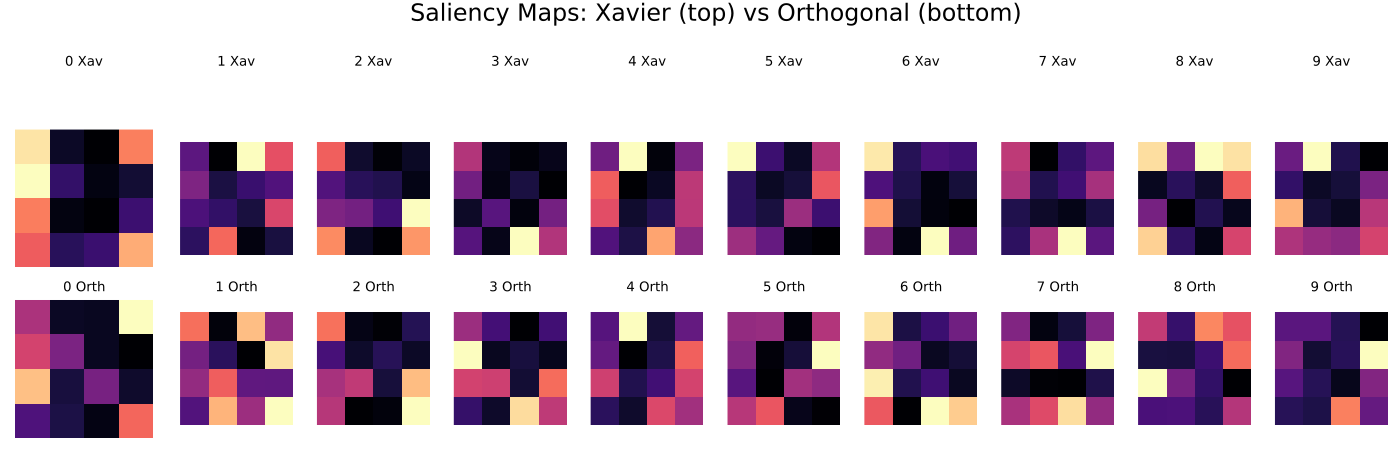

Saved publication figure to: ..\results\figures\saliency_maps.png


In [15]:
# Top row: Xavier  |  Bottom row: Orthogonal
plts = []

for (i, digit) in enumerate(0:9)
    px = heatmap(sal_xavier[i]',
        color=:magma, colorbar=false,
        title="$(digit) Xav",
        titlefontsize=9, aspect_ratio=:equal,
        axis=false, ticks=false,
        top_margin=15Plots.mm  # Pushes the top row down to make room for the main title
    )
    push!(plts, px)
end

for (i, digit) in enumerate(0:9)
    po = heatmap(sal_ortho[i]',
        color=:magma, colorbar=false,
        title="$(digit) Orth",
        titlefontsize=9, aspect_ratio=:equal,
        axis=false, ticks=false
    )
    push!(plts, po)
end

# plot_titlevspan reserves 12% of the vertical space specifically for the main title
fig_sal = plot(plts..., layout=(2, 10), size=(1400, 450),
    plot_title="Saliency Maps: Xavier (top) vs Orthogonal (bottom)",
    plot_titlevspan=0.12 
)

display(fig_sal)

# Save the figure as a high-resolution PNG for the paper
sal_path = joinpath(OUT_DIR, "figures", "saliency_maps.png")
savefig(fig_sal, sal_path)
println("Saved publication figure to: $sal_path")

### 7.5 Zoomed Demo — Original Image + Both Saliency Maps

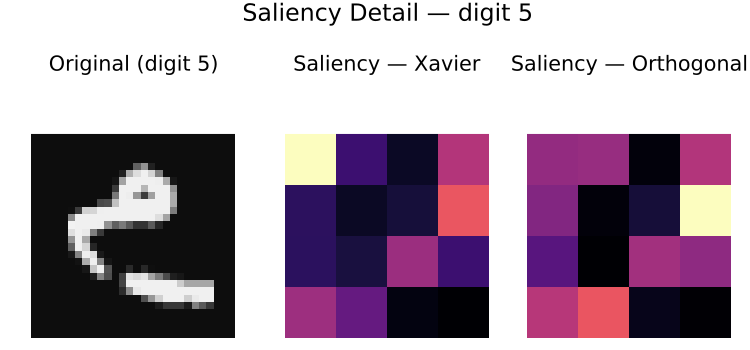

Saved publication figure to: ..\results\figures\saliency_demo_digit5.png


In [17]:
# Showcase digit 5 (index 6 in 0-based list)
DEMO_DIGIT = 5
di = DEMO_DIGIT + 1   # 1-based index into sample_indices
img_demo = test_x[:, :, sample_indices[di]]

p_orig = heatmap(img_demo',
    color=:grays, colorbar=false,
    title="Original (digit $DEMO_DIGIT)",
    aspect_ratio=:equal, axis=false, ticks=false,
    top_margin=15Plots.mm  # FIX: Push subplot down to avoid overlap
)

p_xav = heatmap(sal_xavier[di]',
    color=:magma, colorbar=false,
    title="Saliency — Xavier",
    aspect_ratio=:equal, axis=false, ticks=false,
    top_margin=15Plots.mm  # FIX: Push subplot down
)

p_ort = heatmap(sal_ortho[di]',
    color=:magma, colorbar=false,
    title="Saliency — Orthogonal",
    aspect_ratio=:equal, axis=false, ticks=false,
    top_margin=15Plots.mm  # FIX: Push subplot down
)

# FIX: Added plot_titlevspan and increased height to 350
fig_demo = plot(p_orig, p_xav, p_ort, layout=(1, 3), size=(750, 350),
    plot_title="Saliency Detail — digit $DEMO_DIGIT",
    plot_titlevspan=0.15 
)

display(fig_demo)

# FIX: Changed extension to .png
demo_path = joinpath(OUT_DIR, "figures", "saliency_demo_digit$(DEMO_DIGIT).png")
savefig(fig_demo, demo_path)
println("Saved publication figure to: $demo_path")

## 8. Jacobian Condition Number Plots

Plot $\kappa(J_i)$ at each measured epoch for both models and both transformer blocks.  
These were computed in the training loop and stored in `log["jacobian_conds"]`.

In [18]:
log_xavier = load(joinpath(OUT_DIR, "logs", "training_log_xavier.jld2"),     "log")
log_ortho  = load(joinpath(OUT_DIR, "logs", "training_log_orthogonal.jld2"), "log")

println("Training logs loaded ✓")

Training logs loaded ✓


In [19]:
# Extract (epoch, κ) pairs for each block — skip epochs where Jacobian was not computed
function extract_jac_series(log)
    epochs = Int[]
    kappas = [Float64[] for _ in 1:NUM_BLOCKS]
    for (ep, jc) in zip(log["epoch"], log["jacobian_conds"])
        isempty(jc) && continue
        push!(epochs, ep)
        for b in 1:min(NUM_BLOCKS, length(jc))
            push!(kappas[b], Float64(jc[b]))
        end
    end
    return epochs, kappas
end

ep_x, kap_x = extract_jac_series(log_xavier)
ep_o, kap_o = extract_jac_series(log_ortho)

println("Jacobian-measured epochs (Xavier):     $ep_x")
println("Jacobian-measured epochs (Orthogonal): $ep_o")

Jacobian-measured epochs (Xavier):     [1, 5, 10, 15]
Jacobian-measured epochs (Orthogonal): [1, 5, 10, 15]


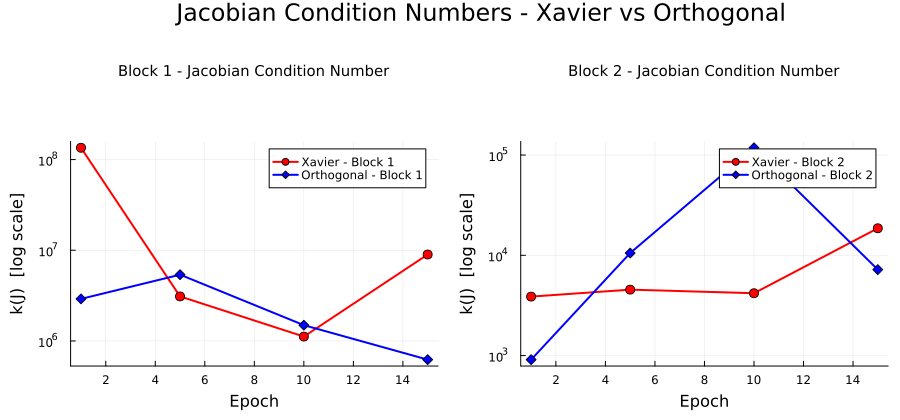

Saved publication figure to: ..\results\figures\jacobian_condition_numbers.png


In [21]:
jac_plots = []

for b in 1:NUM_BLOCKS
    pj = plot(
        ep_x, kap_x[b],
        label="Xavier - Block $b",
        lw=2, marker=:circle, markersize=5, color=:red,
        xlabel="Epoch", ylabel="k(J)  [log scale]",
        title="Block $b - Jacobian Condition Number",
        titlefontsize=10,
        yscale=:log10, grid=true, legend=:topright,
        top_margin=15Plots.mm  # Push subplot down to avoid title overlap
    )
    plot!(pj, ep_o, kap_o[b],
        label="Orthogonal - Block $b",
        lw=2, marker=:diamond, markersize=5, color=:blue
    )
    push!(jac_plots, pj)
end

# Reserve 15% of vertical space for the main title and bump height to 420
fig_jac = plot(jac_plots..., layout=(1, NUM_BLOCKS), size=(900, 420),
    plot_title="Jacobian Condition Numbers - Xavier vs Orthogonal",
    plot_titlevspan=0.15,
    bottom_margin=5Plots.mm,
    left_margin=5Plots.mm
)

display(fig_jac)

# Save as PNG
jac_path = joinpath(OUT_DIR, "figures", "jacobian_condition_numbers.png")
savefig(fig_jac, jac_path)
println("Saved publication figure to: $jac_path")

## 9. Gradient Norm Heatmaps — Gradient Flow Visualization

### 9.1 Final-Epoch Bar Chart

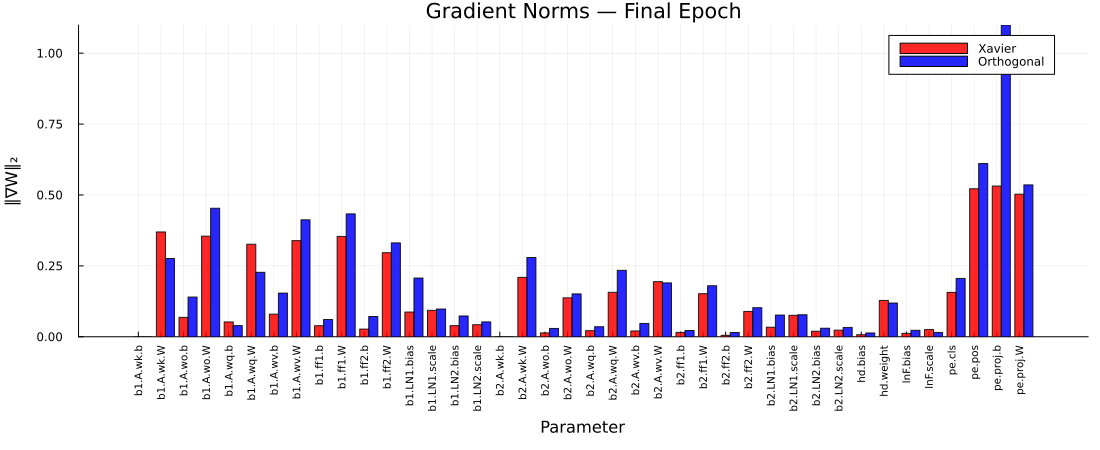

Saved publication figure to: ..\results\figures\gradient_norms_barchart.png


In [23]:
gn_x = log_xavier["grad_norms"][end]
gn_o = log_ortho["grad_norms"][end]

all_keys   = sort(collect(union(keys(gn_x), keys(gn_o))))
vals_x     = [haskey(gn_x, k) ? gn_x[k] : 0.0 for k in all_keys]
vals_o     = [haskey(gn_o, k) ? gn_o[k] : 0.0 for k in all_keys]

# Short display names for the x-axis
short_keys = replace.(all_keys,
    "blocks[" => "b", "]." => ".", "patch_embed." => "pe.",
    "ln_final" => "lnF", "attn." => "A.",
    ".weight" => ".W", ".bias" => ".b",
    "ff.fc" => "ff", "ln" => "LN", "diag." => "",
    "head." => "hd.", "cls_token" => "cls", "pos_embed" => "pos"
)

n = length(all_keys)

# FIX: Added bottom_margin so the 90-degree labels don't get cut off, bumped height to 450
fig_gnorm = bar(
    1:n, vals_x,
    label="Xavier", bar_width=0.4, alpha=0.85, color=:red,
    xlabel="Parameter", ylabel="∥∇W∥₂",
    title="Gradient Norms — Final Epoch",
    xticks=(1:n, short_keys), xrotation=90, xtickfontsize=7,
    size=(1100, 450), legend=:topright, 
    bottom_margin=15Plots.mm, left_margin=5Plots.mm
)
bar!(fig_gnorm, (1:n) .+ 0.4, vals_o,
    label="Orthogonal", bar_width=0.4, alpha=0.85, color=:blue
)

display(fig_gnorm)

# FIX: Changed extension to .png
gnorm_path = joinpath(OUT_DIR, "figures", "gradient_norms_barchart.png")
savefig(fig_gnorm, gnorm_path)
println("Saved publication figure to: $gnorm_path")

### 9.2 Gradient Flow Heatmap — All Epochs

In [24]:
epochs_vec = log_xavier["epoch"]
E = length(epochs_vec)

# Build (n_params × E) matrices
function grad_matrix(log, keys_list)
    n = length(keys_list)
    M = zeros(Float64, n, length(log["epoch"]))
    for (e, gn) in enumerate(log["grad_norms"])
        for (i, k) in enumerate(keys_list)
            M[i, e] = haskey(gn, k) ? Float64(gn[k]) : 0.0
        end
    end
    return M
end

mat_x = grad_matrix(log_xavier, all_keys)
mat_o = grad_matrix(log_ortho,  all_keys)

println("Gradient matrices built: $(size(mat_x))  (params × epochs)")

Gradient matrices built: (40, 15)  (params × epochs)


In [ ]:
ph_x = heatmap(1:E, 1:n, mat_x,
    xlabel="Epoch", ylabel="Parameter index",
    title="Xavier — ∥∇W∥₂ per epoch",
    color=:YlOrRd, colorbar_title="norm",
    xticks=(1:E, string.(epochs_vec)), xrotation=90,
    ytickfontsize=5
)

ph_o = heatmap(1:E, 1:n, mat_o,
    xlabel="Epoch", ylabel="Parameter index",
    title="Orthogonal — ∥∇W∥₂ per epoch",
    color=:YlOrRd, colorbar_title="norm",
    xticks=(1:E, string.(epochs_vec)), xrotation=90,
    ytickfontsize=5
)

fig_heat = plot(ph_x, ph_o, layout=(1, 2), size=(1100, 600),
    plot_title="Gradient Flow Heatmap — Xavier vs Orthogonal",
    margin=5Plots.mm
)

display(fig_heat)

heat_path = joinpath(OUT_DIR, "figures", "gradient_flow_heatmap.pdf")
savefig(fig_heat, heat_path)
println("Saved: $heat_path")

## 10. Per-Class Accuracy Breakdown

In [ ]:
function per_class_accuracy(model, patches, labels_vec)
    logits = model(patches)          # (NUM_CLASSES, N)
    preds  = onecold(logits) .- 1    # 0-indexed digits
    truth  = labels_vec              # already 0-indexed
    Float64[sum(preds[truth .== c] .== c) / max(1, sum(truth .== c)) for c in 0:9]
end

ca_x = per_class_accuracy(model_xavier, test_patches, test_y)
ca_o = per_class_accuracy(model_ortho,  test_patches, test_y)

println("\nPer-class Test Accuracy:")
println(rpad("Digit", 8) * rpad("Xavier %", 12) * "Ortho %")
println("-"^32)
for d in 0:9
    println(rpad(string(d), 8) *
            rpad(string(round(100*ca_x[d+1]; digits=2)), 12) *
            string(round(100*ca_o[d+1]; digits=2)))
end

In [ ]:
fig_class = groupedbar(
    hcat(ca_x .* 100, ca_o .* 100),
    bar_position=:dodge, bar_width=0.7, alpha=0.85,
    xticks=(1:10, string.(0:9)),
    xlabel="Digit class", ylabel="Accuracy (%)",
    label=["Xavier" "Orthogonal"],
    color=[:red :blue],
    title="Per-Class Test Accuracy",
    size=(700, 380), legend=:bottomright, ylims=(90, 100)
)

display(fig_class)

cls_path = joinpath(OUT_DIR, "figures", "per_class_accuracy.pdf")
savefig(fig_class, cls_path)
println("Saved: $cls_path")

## 11. Summary Table

All output figures are saved to `results/figures/`.

| Figure | Filename | Description |
|--------|----------|-------------|
| Saliency maps (all digits) | `saliency_maps.pdf` | 2×10 grid, Xavier top / Orthogonal bottom |
| Saliency detail | `saliency_demo_digit5.pdf` | original + two saliency panels |
| Jacobian κ over epochs | `jacobian_condition_numbers.pdf` | per block, log-scale |
| Gradient norms bar chart | `gradient_norms_barchart.pdf` | final epoch, all parameters |
| Gradient flow heatmap | `gradient_flow_heatmap.pdf` | all epochs × all parameters |
| Per-class accuracy | `per_class_accuracy.pdf` | grouped bar by digit |

**Key interpretations for the paper:**

- **Saliency maps** — if orthogonal initialization yields more spatially concentrated gradients, the saliency patches will highlight sharper, more discriminative regions (stroke-level features of each digit).  
- **Jacobian condition numbers** — the proposal (§2) predicts orthogonal weights keep κ(J) closer to 1. Verify whether the curves for Block 1 and Block 2 confirm this, especially at epoch 1 vs epoch 15.  
- **Gradient flow heatmap** — uniform colour intensity across the parameter axis would indicate balanced gradient propagation (no systematic vanishing in early layers).